In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

In [2]:
df=pd.read_csv("Heart_Disease_Prediction.csv")

In [3]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [4]:
df.shape

(268, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      268 non-null    int64  
 1   Sex                      268 non-null    int64  
 2   Chest pain type          268 non-null    int64  
 3   BP                       268 non-null    int64  
 4   Cholesterol              268 non-null    int64  
 5   FBS over 120             268 non-null    int64  
 6   EKG results              268 non-null    int64  
 7   Max HR                   268 non-null    int64  
 8   Exercise angina          268 non-null    int64  
 9   ST depression            268 non-null    float64
 10  Slope of ST              268 non-null    int64  
 11  Number of vessels fluro  268 non-null    int64  
 12  Thallium                 268 non-null    int64  
 13  Heart Disease            268 non-null    object 
dtypes: float64(1), int64(12), 

In [6]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000
mean,54.376866,0.675373,3.167910,131.205224,249.738806,0.149254,1.022388,149.839552,0.328358,1.050746,1.582090,0.664179,4.697761
std,9.109187,0.469111,0.950939,17.833994,51.711448,0.357005,0.997874,23.111203,0.470495,1.148472,0.615633,0.935717,1.943508
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,47.750000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,154.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,278.000000,0.000000,2.000000,166.250000,1.000000,1.650000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [7]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
hh=df.select_dtypes(include=["object"]).columns
for i in hh:
    print(f"unique values in {i}")
    print(df[i].unique())
    print(".......................")

unique values in Heart Disease
['Presence' 'Absence']
.......................


In [10]:
nc=df.select_dtypes(include="number")
for i in nc:
    print(i)

Age
Sex
Chest pain type
BP
Cholesterol
FBS over 120
EKG results
Max HR
Exercise angina
ST depression
Slope of ST
Number of vessels fluro
Thallium


In [11]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [12]:
df.columns = df.columns.str.replace(' ', '_')

In [13]:
df.columns

Index(['Age', 'Sex', 'Chest_pain_type', 'BP', 'Cholesterol', 'FBS_over_120',
       'EKG_results', 'Max_HR', 'Exercise_angina', 'ST_depression',
       'Slope_of_ST', 'Number_of_vessels_fluro', 'Thallium', 'Heart_Disease'],
      dtype='object')

<Axes: >

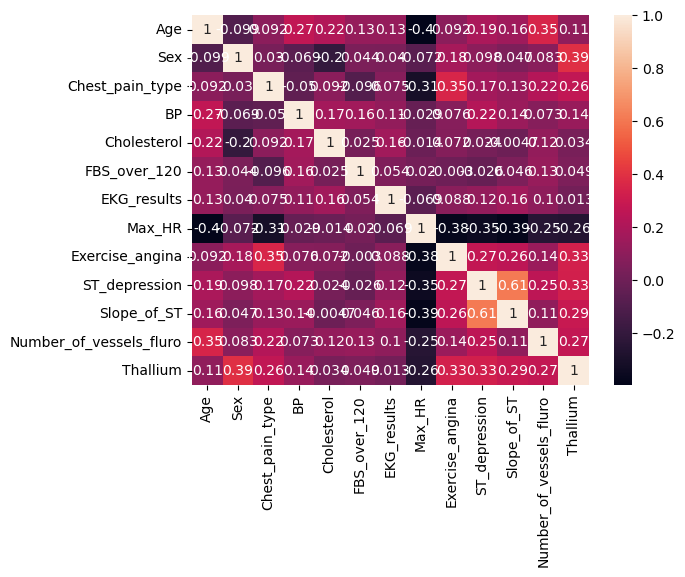

In [14]:
sns.heatmap(df.corr(),annot=True)

In [15]:
xa=df.drop("Heart_Disease",axis=1)

In [16]:
x=pd.get_dummies(data=xa,drop_first=True)
y=df["Heart_Disease"]

In [17]:
trainr2=[]
testr2=[]
cv=[]

for i in range(0,100):
    from sklearn.model_selection import train_test_split
    xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=i)
    
    #modeling
    from sklearn.linear_model import LogisticRegression
    model=LogisticRegression()
    model.fit(xtrain,ytrain)
    #print(model.intercept_)
    #print(model.coef_)
    #prediction
    ypredtest=model.predict(xtest)
    ypredtrain=model.predict(xtrain)
    #evalution
    trainr2.append(model.score(xtrain,ytrain))
    testr2.append(model.score(xtest,ytest))
    from sklearn.model_selection import cross_val_score
    cv.append(cross_val_score(model,x,y,cv=5,).mean())

hh=pd.DataFrame({"train":trainr2,"test":testr2,"cv":cv})
#print(hh)
gg=hh[(abs(hh["train"]-hh["test"])<=0.05) & (abs(hh["test"]-hh["cv"])<=0.05)]
#print(gg)
a=gg[gg["test"]==gg["test"].max()].index.to_list()[0]
print(a)

6


In [18]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=6)

In [19]:
from sklearn.linear_model import LogisticRegression
lmodel=LogisticRegression()
lmodel.fit(xtrain,ytrain)


ypredtrain=lmodel.predict(xtrain)
ypredtest=lmodel.predict(xtest)

from sklearn.metrics import accuracy_score
ltr=accuracy_score(ytrain,ypredtrain)
lts=accuracy_score(ytest,ypredtest)
print("train_accuracy",accuracy_score(ytrain,ypredtrain))
print("test_accuracy",accuracy_score(ytest,ypredtest))

from sklearn.model_selection import cross_val_score
cv=cross_val_score(lmodel,x,y,cv=5)
p=cv.mean()
print("cross_val_score",p)

train_accuracy 0.8411214953271028
test_accuracy 0.8888888888888888
cross_val_score 0.8470300489168414


In [20]:
from sklearn.metrics import confusion_matrix
x1=confusion_matrix(ytest,ypredtest)
print("confusion matrix",x1)

from sklearn.metrics import classification_report 
pf=classification_report(ytest,ypredtest)
print("classification metrix",pf)

confusion matrix [[24  1]
 [ 5 24]]
classification metrix               precision    recall  f1-score   support

     Absence       0.83      0.96      0.89        25
    Presence       0.96      0.83      0.89        29

    accuracy                           0.89        54
   macro avg       0.89      0.89      0.89        54
weighted avg       0.90      0.89      0.89        54



In [21]:
import pickle

In [22]:
pickle.dump(model,open("heart_disease_model.pkl","wb"))

In [23]:
x.columns

Index(['Age', 'Sex', 'Chest_pain_type', 'BP', 'Cholesterol', 'FBS_over_120',
       'EKG_results', 'Max_HR', 'Exercise_angina', 'ST_depression',
       'Slope_of_ST', 'Number_of_vessels_fluro', 'Thallium'],
      dtype='object')

In [24]:
bb={'Age':67, 'Sex':1, 'Chest_pain_type':4, 'BP':160, 'Cholesterol':286, 'FBS_over_120':0,
       'EKG_results':2, 'Max_HR':108, 'Exercise_angina':1, 'ST_depression':1.5,
       'Slope_of_ST':2, 'Number_of_vessels_fluro':3, 'Thallium':3}

In [25]:
bb

{'Age': 67,
 'Sex': 1,
 'Chest_pain_type': 4,
 'BP': 160,
 'Cholesterol': 286,
 'FBS_over_120': 0,
 'EKG_results': 2,
 'Max_HR': 108,
 'Exercise_angina': 1,
 'ST_depression': 1.5,
 'Slope_of_ST': 2,
 'Number_of_vessels_fluro': 3,
 'Thallium': 3}

In [26]:
dd=pd.DataFrame(data=bb,index=[0])

In [27]:
dd

,Age,Sex,Chest_pain_type,BP,Cholesterol,FBS_over_120,EKG_results,Max_HR,Exercise_angina,ST_depression,Slope_of_ST,Number_of_vessels_fluro,Thallium
0,67,1,4,160,286,0,2,108,1,1.5,2,3,3


In [28]:
lmodel.predict(dd)

array(['Presence'], dtype=object)

In [29]:
b={'Age':57, 'Sex':1, 'Chest_pain_type':4, 'BP':140, 'Cholesterol':192, 'FBS_over_120':0,
       'EKG_results':0, 'Max_HR':148, 'Exercise_angina':0, 'ST_depression':0.4,
       'Slope_of_ST':2, 'Number_of_vessels_fluro':0, 'Thallium':6}

In [30]:
d=pd.DataFrame(data=b,index=[0])

In [31]:
lmodel.predict(d)

array(['Absence'], dtype=object)